In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dirty_cafe_sales.csv')

In [4]:
df.shape

(10000, 8)

In [8]:
df.sample(8)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1970,TXN_3003876,Cookie,3,1.0,3.0,Cash,ERROR,2023-08-27
3310,TXN_2580487,Cake,1,3.0,3.0,NaN,Takeaway,2023-01-13
6047,TXN_1696300,Cookie,1,1.0,1.0,Digital Wallet,In-store,2023-05-28
9043,TXN_9438576,Cookie,1,1.0,1.0,Credit Card,In-store,2023-05-05
683,TXN_7946489,Juice,1,3.0,3.0,Cash,Takeaway,2023-09-11
506,TXN_3981449,Smoothie,2,4.0,8.0,Cash,In-store,2023-06-21
301,TXN_4912930,Smoothie,3,4.0,12.0,Credit Card,In-store,2023-02-26
7212,TXN_1505837,Sandwich,3,4.0,12.0,Credit Card,In-store,2023-12-15


In [9]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [12]:
df.sample()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1644,TXN_3915802,Coffee,3,2.0,6.0,Cash,Takeaway,2023-12-16


In [23]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [24]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9667 non-null   object 
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    7421 non-null   object 
 6   Location          6735 non-null   object 
 7   Transaction Date  9841 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [29]:
# 2. Case 1: Fill missing Quantity (if Price Per Unit & Total Spent exist)
df['Quantity'] = np.where(
    df['Quantity'].isna() & df['Price Per Unit'].notna() & df['Total Spent'].notna(),
    df['Total Spent'] / df['Price Per Unit'],
    df['Quantity']
)

# 3. Case 2: Fill missing Price Per Unit (if Quantity & Total Spent exist)
df['Price Per Unit'] = np.where(
    df['Price Per Unit'].isna() & df['Quantity'].notna() & df['Total Spent'].notna(),
    df['Total Spent'] / df['Quantity'],
    df['Price Per Unit']
)

# 4. Case 3: Fill missing Total Spent (if Quantity & Price Per Unit exist)
df['Total Spent'] = np.where(
    df['Total Spent'].isna() & df['Quantity'].notna() & df['Price Per Unit'].notna(),
    df['Quantity'] * df['Price Per Unit'],
    df['Total Spent']
)

In [30]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity              38
Price Per Unit        38
Total Spent           40
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [31]:
# Drop rows where Quantity, Price, OR Total Spent are still missing
df.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent'], inplace=True)

In [33]:
df.isnull().sum()

Transaction ID         0
Item                 331
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2564
Location            3249
Transaction Date     157
dtype: int64

In [34]:
df.shape

(9942, 8)

In [36]:
round(df.duplicated().sum())

0

In [37]:
df.sample()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1897,TXN_9298053,Juice,5.0,3.0,15.0,Cash,In-store,2023-06-29


In [44]:
df.groupby('Item')['Price Per Unit'].unique()

Item
Cake                                 [3.0]
Coffee                               [2.0]
Cookie                               [1.0]
ERROR       [1.5, 3.0, 5.0, 4.0, 2.0, 1.0]
Juice                                [3.0]
Salad                                [5.0]
Sandwich                             [4.0]
Smoothie                             [4.0]
Tea                                  [1.5]
UNKNOWN     [3.0, 1.0, 5.0, 4.0, 1.5, 2.0]
Name: Price Per Unit, dtype: object

In [52]:
df.isnull().sum()

Transaction ID         0
Item                 474
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2564
Location            3249
Transaction Date     157
dtype: int64

In [45]:
# Treating 'ERROR' and 'UNKNOWN' as missing values in Item

df['Item']= df['Item'].replace(['ERROR','UNKNOWN','Error','Unknown'], np.nan)

In [46]:
df.groupby('Item')['Price Per Unit'].unique()

Item
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
Name: Price Per Unit, dtype: object

In [50]:
priced_to_item = {
    1.0:'Cookie',
    1.5:'Tea',
    2:'Coffee',
    5:'Salad'}

df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(priced_to_item))

In [51]:
df.isnull().sum()

Transaction ID         0
Item                 474
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2564
Location            3249
Transaction Date     157
dtype: int64

In [53]:
# Any remaining NaN items (the $3.0 and $4.0 items) get labeled cleanly
df['Item'] = df['Item'].fillna('Unknown')

In [54]:
df.isnull().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2564
Location            3249
Transaction Date     157
dtype: int64

In [55]:
df.head(2)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16


In [58]:
df.groupby('Payment Method') ['Payment Method'].unique()

Payment Method
Cash                        [Cash]
Credit Card          [Credit Card]
Digital Wallet    [Digital Wallet]
ERROR                      [ERROR]
UNKNOWN                  [UNKNOWN]
Name: Payment Method, dtype: object

In [59]:
df['Payment Method'] = df['Payment Method'].replace(['ERROR','UNKNOWN','Error','Unknown'], np.nan)

In [60]:
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
4935,TXN_8099340,Tea,4.0,1.5,6.0,NaN,In-store,2023-04-23
6299,TXN_2206639,Coffee,4.0,2.0,8.0,Cash,Takeaway,2023-06-29
7088,TXN_9279935,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-02
626,TXN_3469469,Cookie,1.0,1.0,1.0,Digital Wallet,In-store,2023-10-25
7336,TXN_9517548,Coffee,3.0,2.0,6.0,Cash,Takeaway,2023-01-25
963,TXN_8514689,Juice,5.0,3.0,15.0,NaN,NaN,2023-04-15
2584,TXN_3499226,Juice,1.0,3.0,3.0,Credit Card,Takeaway,2023-09-08
4960,TXN_1050323,Juice,1.0,3.0,3.0,NaN,In-store,2023-03-10
7591,TXN_9486849,Cake,1.0,3.0,3.0,Cash,Takeaway,2023-03-17
9093,TXN_1180397,Smoothie,3.0,4.0,12.0,Credit Card,Takeaway,2023-04-05


In [61]:
df['Payment Method'] = df['Payment Method'].fillna('Unknown')
# 3. Strip trailing/leading spaces
df['Payment Method'] = df['Payment Method'].astype(str).str.strip()

In [70]:
df['Payment Method'].value_counts()

Payment Method
Unknown           3158
Digital Wallet    2280
Credit Card       2260
Cash              2244
Name: count, dtype: int64

In [71]:
df.isnull().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method         0
Location            3249
Transaction Date     157
dtype: int64

In [74]:
df.sample(15)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
5457,TXN_3622194,Cake,1.0,3.0,3.0,Digital Wallet,NaN,2023-06-26
7642,TXN_4831311,Coffee,2.0,2.0,4.0,Cash,Takeaway,2023-07-15
9243,TXN_4508067,Smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-03-19
4362,TXN_7022398,Sandwich,4.0,4.0,16.0,Unknown,NaN,2023-12-23
7886,TXN_1770648,Sandwich,4.0,4.0,16.0,Credit Card,NaN,2023-09-30
7528,TXN_6867995,Cookie,3.0,1.0,3.0,Digital Wallet,In-store,2023-10-15
4221,TXN_6272674,Coffee,3.0,2.0,6.0,Cash,NaN,2023-09-12
5083,TXN_3725152,Coffee,5.0,2.0,10.0,Unknown,NaN,2023-07-08
5389,TXN_4612930,Juice,2.0,3.0,6.0,Unknown,NaN,2023-08-13
6029,TXN_4721830,Sandwich,3.0,4.0,12.0,Unknown,NaN,2023-11-15


In [73]:
df.groupby('Location')['Location'].unique()

Location
ERROR          [ERROR]
In-store    [In-store]
Takeaway    [Takeaway]
UNKNOWN      [UNKNOWN]
Name: Location, dtype: object

In [75]:
# 1. Convert dirty error strings to NaN
df['Location'] = df['Location'].replace(['ERROR', 'UNKNOWN', 'Error', 'Unknown'], np.nan)

# 2. Fill missing values with 'Unknown'
df['Location'] = df['Location'].fillna('Unknown')

# 3. Strip whitespace
df['Location'] = df['Location'].astype(str).str.strip()

In [76]:
df.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    157
dtype: int64

In [77]:
df['Location'].value_counts(dropna=False)

Location
Unknown     3940
Takeaway    3004
In-store    2998
Name: count, dtype: int64

In [80]:
df.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
4504,TXN_5613875,Tea,5.0,1.5,7.5,Unknown,In-store,UNKNOWN
6690,TXN_5179156,Coffee,5.0,2.0,10.0,Unknown,In-store,2023-10-25
2358,TXN_4811887,Cake,2.0,3.0,6.0,Cash,In-store,2023-02-11
1098,TXN_9358958,Smoothie,1.0,4.0,4.0,Unknown,Takeaway,2023-05-08
6383,TXN_8443384,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-02-13
805,TXN_6609947,Unknown,3.0,3.0,9.0,Digital Wallet,In-store,2023-05-29
8795,TXN_4623303,Smoothie,3.0,4.0,12.0,Unknown,In-store,2023-01-29
9567,TXN_3674876,Smoothie,5.0,4.0,20.0,Cash,Takeaway,NaN
3236,TXN_4520062,Tea,2.0,1.5,3.0,Unknown,In-store,2023-01-10
9052,TXN_3269434,Juice,1.0,3.0,3.0,Cash,Unknown,2023-02-01


# Drop rows where the Transaction Date is missing
y default, .dropna() always operates on rows (because its default setting is axis=0).

When you write subset=['Transaction Date'], you are telling pandas: "Go through the dataset row by row. Look strictly at the Transaction Date column. If a row has a missing value in that specific column, drop that row."

If you actually wanted to drop the entire column, you would use a completely different method: df.drop(columns=['Transaction Date']).


In [81]:
df.dropna(subset=['Transaction Date'], inplace=True)

In [82]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [84]:
df.shape

(9785, 8)

In [85]:
df.describe()

,Quantity,Price Per Unit,Total Spent
count,9785.000000,9785.000000,9785.000000
mean,3.024732,2.948697,8.931732
std,1.420704,1.278847,6.003592
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9785 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9785 non-null   object 
 1   Item              9785 non-null   object 
 2   Quantity          9785 non-null   float64
 3   Price Per Unit    9785 non-null   float64
 4   Total Spent       9785 non-null   float64
 5   Payment Method    9785 non-null   object 
 6   Location          9785 non-null   object 
 7   Transaction Date  9785 non-null   object 
dtypes: float64(3), object(5)
memory usage: 688.0+ KB


**REAL memory usage:**

In [88]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 9785 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9785 non-null   object 
 1   Item              9785 non-null   object 
 2   Quantity          9785 non-null   float64
 3   Price Per Unit    9785 non-null   float64
 4   Total Spent       9785 non-null   float64
 5   Payment Method    9785 non-null   object 
 6   Location          9785 non-null   object 
 7   Transaction Date  9785 non-null   object 
dtypes: float64(3), object(5)
memory usage: 3.0 MB


In [90]:
# 1. Convert Date to true Datetime safely using errors='coerce'
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# 2. Now that 'ERROR' is properly converted to a missing value (NaT), we can safely drop it
df.dropna(subset=['Transaction Date'], inplace=True)

# 3. Convert repetitive text columns to 'category' (This will MASSIVELY reduce memory!)
categorical_cols = ['Item', 'Payment Method', 'Location']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 4. Quantity can be an integer instead of a float
df['Quantity'] = df['Quantity'].astype(int)

In [91]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9485 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9485 non-null   object        
 1   Item              9485 non-null   category      
 2   Quantity          9485 non-null   int64         
 3   Price Per Unit    9485 non-null   float64       
 4   Total Spent       9485 non-null   float64       
 5   Payment Method    9485 non-null   category      
 6   Location          9485 non-null   category      
 7   Transaction Date  9485 non-null   datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 473.1+ KB


In [93]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 9485 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9485 non-null   object        
 1   Item              9485 non-null   category      
 2   Quantity          9485 non-null   int64         
 3   Price Per Unit    9485 non-null   float64       
 4   Total Spent       9485 non-null   float64       
 5   Payment Method    9485 non-null   category      
 6   Location          9485 non-null   category      
 7   Transaction Date  9485 non-null   datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 955.5 KB


**See the memory usage almost reduced about 2MB**

In [154]:
df.to_csv('Cleaned-CafeSales-Data.csv')

# **EDA**

**What is the most frequently purchased item?**

In [112]:
sns.set_theme(style="whitegrid")

Text(0.5, 0, 'Item Category')

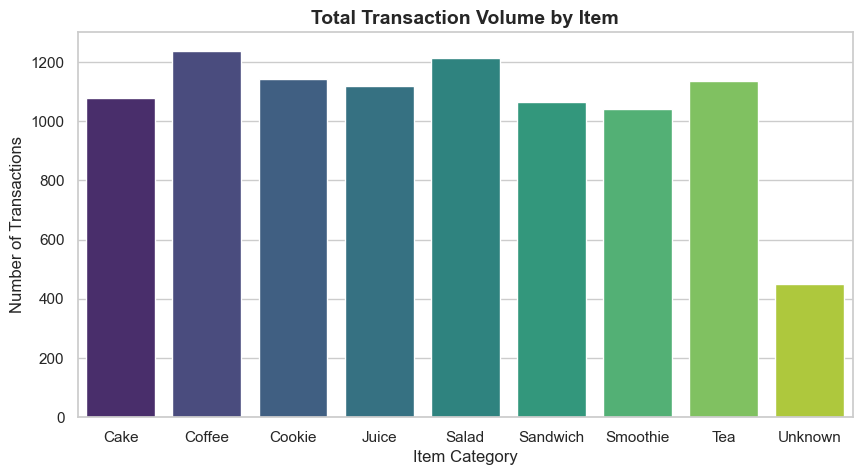

In [155]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Item',palette='viridis',hue='Item')
plt.title('Total Transaction Volume by Item', fontsize=14, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Item Category')
plt.title('Total Transaction Volume by Item', fontsize=14, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Item Category')

**Question 2: Which items actually bring in the most money (Revenue)?**

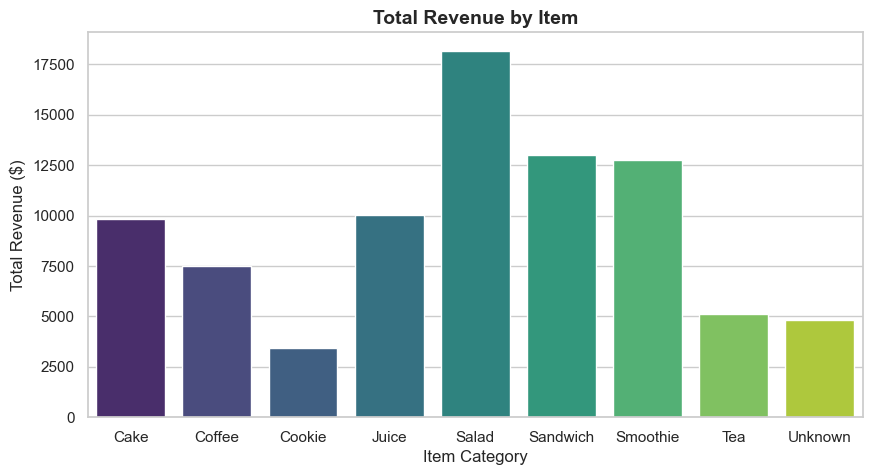

In [134]:
plt.figure(figsize=(10, 5))

# Added estimator=sum and errorbar=None
sns.barplot(
    data=df, 
    x='Item', 
    y='Total Spent', 
    estimator=sum, 
    errorbar=None,
    palette='viridis',
    hue='Item'
)

# Added titles and labels to make it presentation-ready
plt.title('Total Revenue by Item', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Item Category')

plt.show()

**Question 3: How are our sales performing over time?**

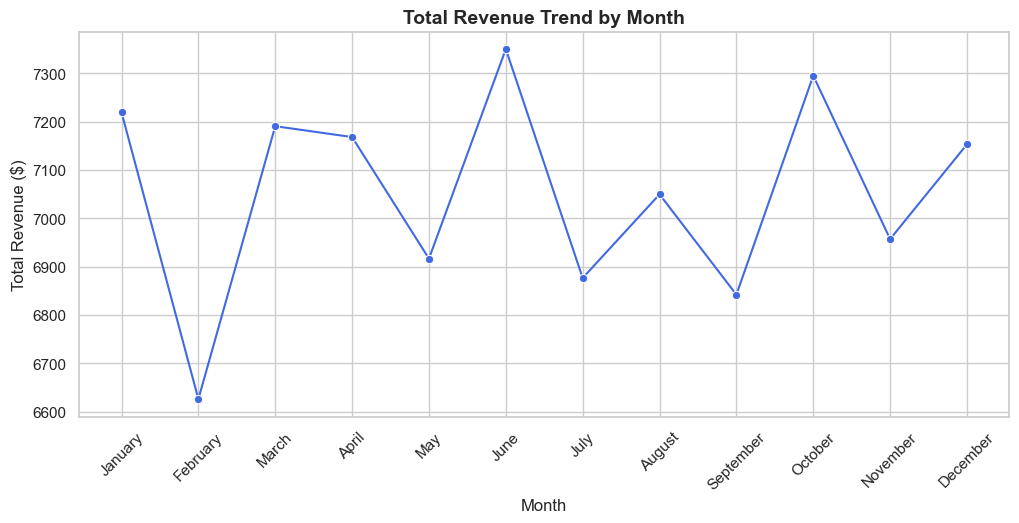

In [138]:
import pandas as pd

# 1. Extract the Month name from the Transaction Date
df['Month'] = df['Transaction Date'].dt.month_name()

# 2. Define the correct calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# ==========================================
# NEW STEP: Force pandas to respect the calendar order
# ==========================================
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 5))

# 3. Create a Line Chart (Seaborn will now automatically respect the ordered category)
sns.lineplot(
    data=df,
    x='Month',
    y='Total Spent',
    estimator=sum,      
    errorbar=None,      
    marker='o',         
    color='royalblue'
)

# 4. Make it presentation-ready
plt.title('Total Revenue Trend by Month', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)

plt.show()

In [139]:
df.sample()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month
8900,TXN_3041142,Smoothie,3,4.0,12.0,Digital Wallet,Unknown,2023-12-22,December


**Question 4: Does Location (In-store vs. Takeaway) change what people buy?**

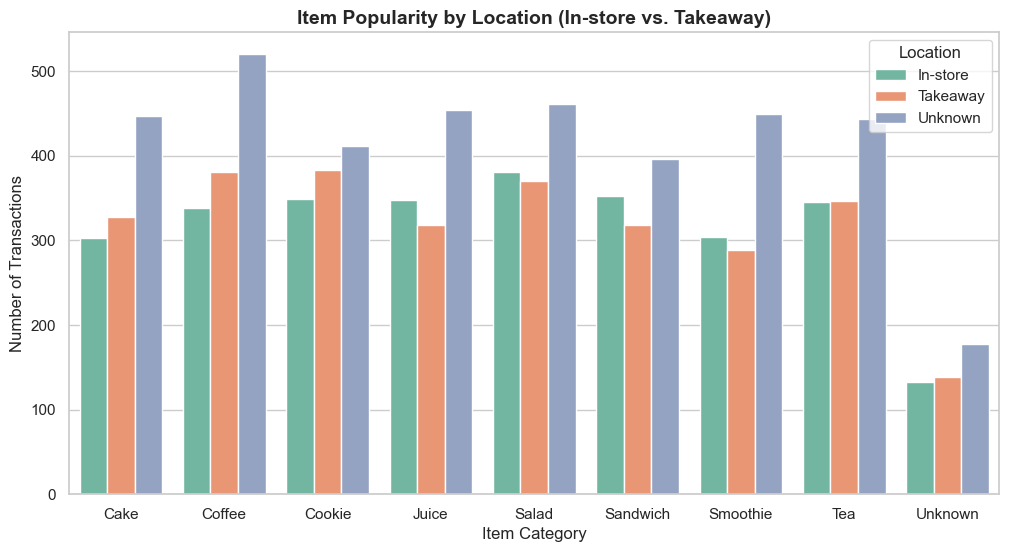

In [143]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='Item',hue='Location', palette='Set2')
plt.title('Item Popularity by Location (In-store vs. Takeaway)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Item Category')
plt.show()

**Question 5: Does the Payment Method affect how much money people spend per order?**

In [146]:
df.head(1)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,September


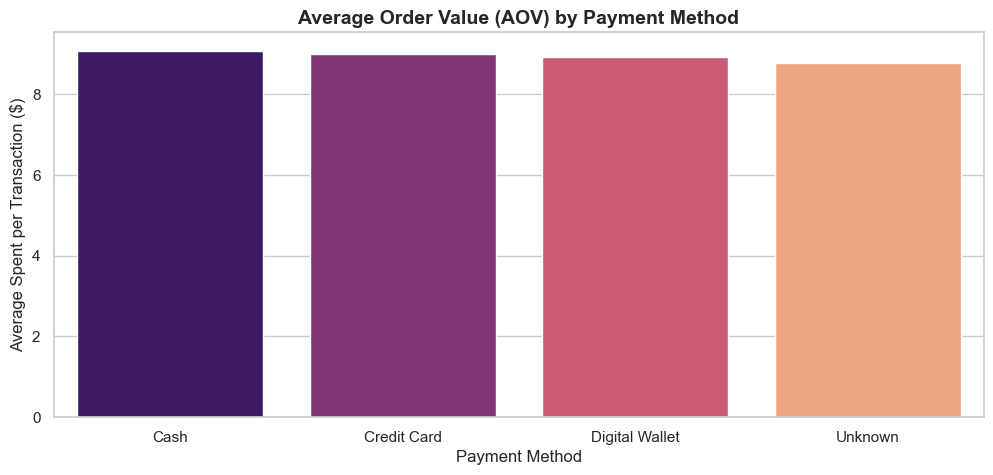

In [149]:
plt.figure(figsize=(12,5))
sns.barplot(data=df,x='Payment Method',y='Total Spent',hue='Payment Method',
            palette='magma',errorbar=None,legend=False)
plt.title('Average Order Value (AOV) by Payment Method', fontsize=14, fontweight='bold')
plt.ylabel('Average Spent per Transaction ($)')
plt.xlabel('Payment Method')
plt.show()

**Question 7: What days of the week are the busiest? (Staffing Analysis**

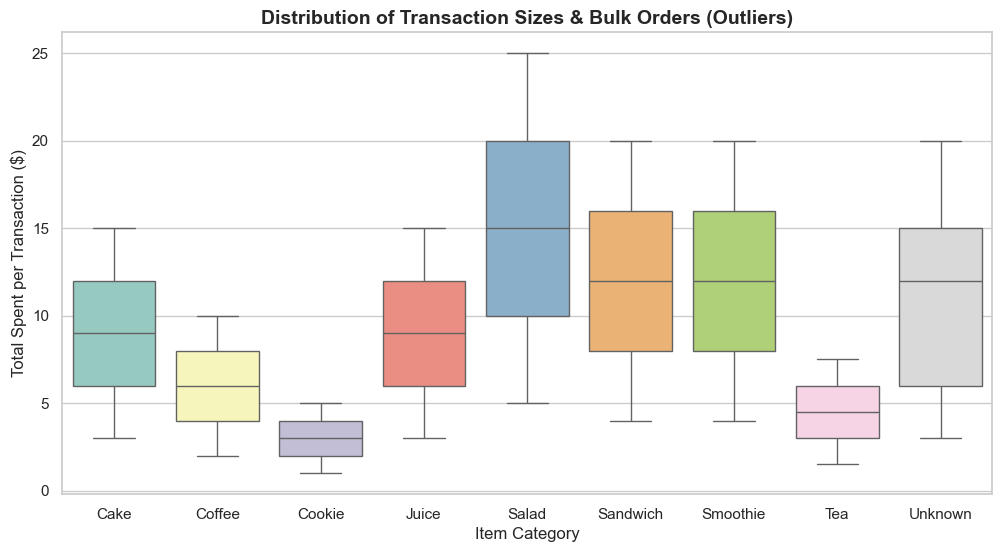

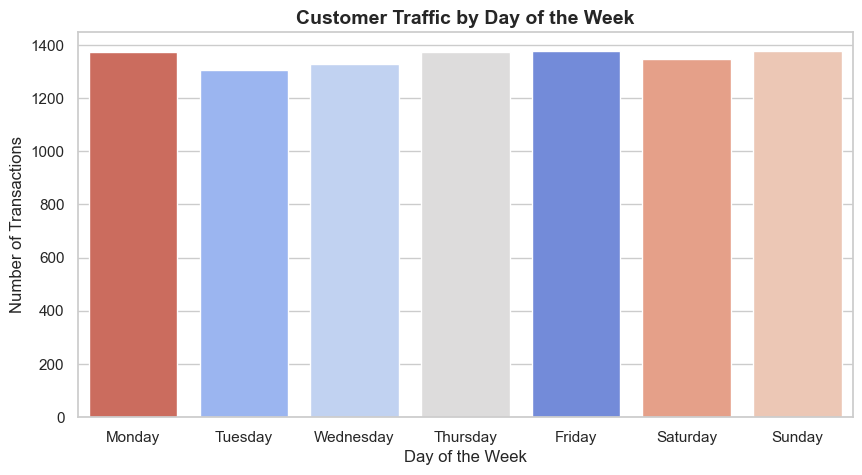

In [150]:
plt.figure(figsize=(12, 6))

# Boxplot shows the distribution and outliers (the dots) for each item
sns.boxplot(
    data=df,
    x='Item',
    y='Total Spent',
    hue='Item',
    palette='Set3',
    legend=False
)

plt.title('Distribution of Transaction Sizes & Bulk Orders (Outliers)', fontsize=14, fontweight='bold')
plt.ylabel('Total Spent per Transaction ($)')
plt.xlabel('Item Category')
plt.show()


# ==========================================
# QUESTION 7: Staffing Analysis (Day of Week)
# ==========================================
# 1. Extract the Day of the Week
df['Day of Week'] = df['Transaction Date'].dt.day_name()

# 2. Define the correct calendar order for the X-axis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))

# 3. Create a countplot to show volume by day
sns.countplot(
    data=df,
    x='Day of Week',
    order=day_order,
    hue='Day of Week',
    palette='coolwarm',
    legend=False
)

plt.title('Customer Traffic by Day of the Week', fontsize=14, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Day of the Week')
plt.show()

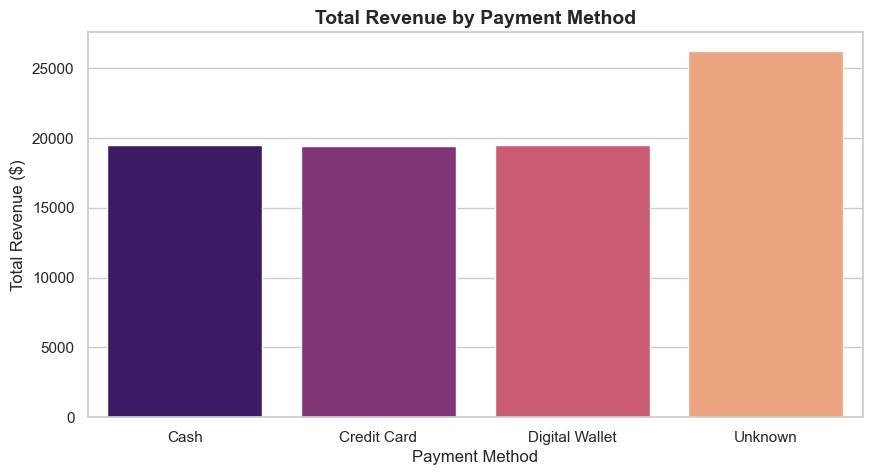

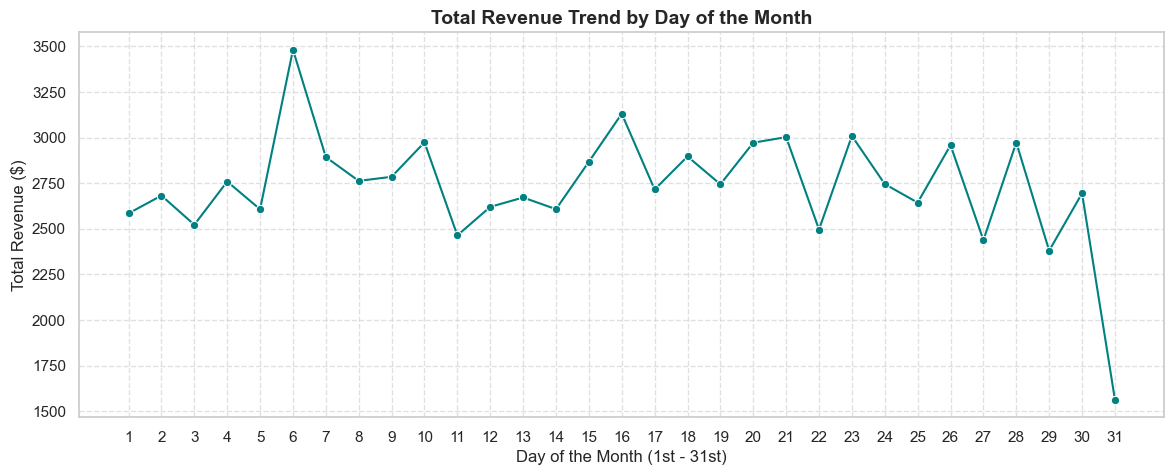

In [151]:
# ==========================================
# ANALYSIS 1: Total Spent by Payment Mode
# ==========================================
plt.figure(figsize=(10, 5))

# We use estimator=sum to get the Total Revenue, not the average!
sns.barplot(
    data=df,
    x='Payment Method',
    y='Total Spent',
    estimator=sum, 
    errorbar=None,
    palette='magma',
    hue='Payment Method',
    legend=False
)

plt.title('Total Revenue by Payment Method', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Payment Method')
plt.show()


# ==========================================
# ANALYSIS 2: Date-wise Revenue in a Month (1st to 31st)
# ==========================================
# 1. Extract the day of the month (returns a number from 1 to 31)
df['Day of Month'] = df['Transaction Date'].dt.day

plt.figure(figsize=(14, 5))

# 2. Use a line plot to show the trend across the month
sns.lineplot(
    data=df,
    x='Day of Month',
    y='Total Spent',
    estimator=sum,
    errorbar=None,
    marker='o',
    color='teal'
)

# Force the X-axis to show every single day from 1 to 31
plt.xticks(range(1, 32))

plt.title('Total Revenue Trend by Day of the Month', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Day of the Month (1st - 31st)')
plt.grid(True, linestyle='--', alpha=0.6) # Adds a light grid for easier reading

plt.show()